# 붓꽃(Iris) 데이터셋으로 붓꽃품종 클러스터링

## 분류/비지도학습 - K-Means clustering


붓꽃 데이터셋

 - 현대 통계학의 아버지, Roland Fisher 가 살아생전 수집한 150개의 붓꽃 데이터
 - 꽃받침 길이(Sepal length), 꽃받침 너비(Sepal width), 꽃잎 길이(Petal length), 꽃잎 너비(Petal width)에 의한 품종분류
 
 ![](https://cdn-images-1.medium.com/freeze/max/1000/1*gwmXliaxIBkY4NQBhoe9JQ.png)


 - 붓꽃 데이터셋
    - https://raw.githubusercontent.com/agtechresearch/MLApplications-Graduate/main/dataset/iris_no_species.csv

### 1) 붓꽃 데이터셋에서 "꽃잎의 길이"와 "너비"만을 가지고 품종 분류를 해보자 (비지도학습, 분류, K-means clustering)


In [1]:
## 필요한 라이브러리 import
import pandas as pd
import matplotlib.pyplot as plt
import warnings

# 경고 메시지 출력 표기 생략
warnings.filterwarnings('ignore')

### 붓꽃 데이터를 읽어온 후, 데이터 전처리(꽃잎의 길이와 너비)

In [2]:
## Iris 데이터 읽어오기
df = pd.read_csv('https://raw.githubusercontent.com/agtechresearch/MLApplications-Graduate/main/dataset/iris_no_species.csv')
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
## 데이터 전처리: Petal length 와 Petal width 만 가지고 클러스터링 (그 외 데이터 삭제)
x_data = df.drop(['SepalLengthCm', 'SepalWidthCm'], axis=1)

x_data

,PetalLengthCm,PetalWidthCm
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2
...,...,...
145,5.2,2.3
146,5.0,1.9
147,5.2,2.0
148,5.4,2.3


### Scatter plot 으로 데이터 가시화 해보기

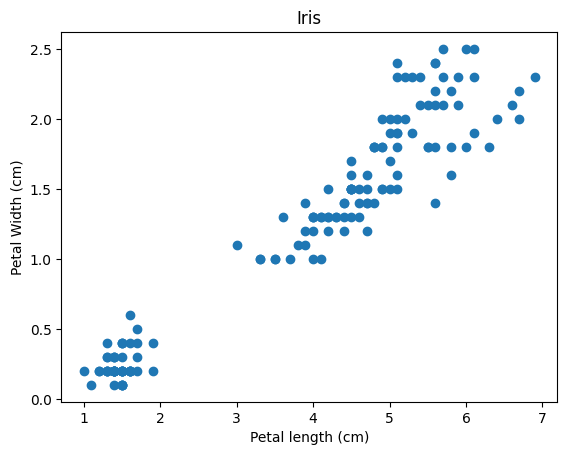

In [4]:
## Scatter plot 으로 데이터 가시화해보기(Visualize)
plt.scatter(x_data['PetalLengthCm'], x_data['PetalWidthCm'])
plt.title('Iris')
plt.xlabel('Petal length (cm)')
plt.ylabel('Petal Width (cm)')
plt.show()

### K-means 에 의한 클러스터링 수행

In [5]:
# 사이킷런에 구현되어 있는 KMeans 함수 import
# KMeans 함수는 K-means clustering 알고리즘을 구현한 클래스
from sklearn.cluster import KMeans

## 클러스터링 수행 by K-means clustering
# 알고리즘 선택과 불러오기 + cluster 수 설정
model = KMeans(n_clusters=3) 

# 모델 학습
model.fit(x_data)

Exception in thread Thread-4 (_readerthread):
Traceback (most recent call last):
  File "d:\Anaconda3\envs\dl\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "d:\Anaconda3\envs\dl\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "d:\Anaconda3\envs\dl\Lib\subprocess.py", line 1601, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xc0 in position 4: invalid start byte


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


### K-means 클러스터링 결과 그림 그려보기

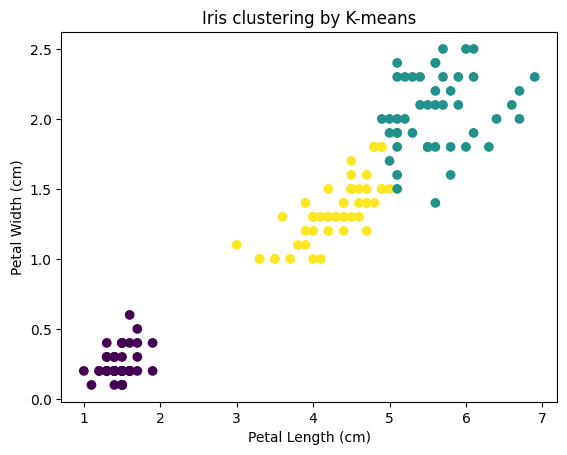

In [6]:
plt.scatter(x_data['PetalLengthCm'], x_data['PetalWidthCm'], c=model.labels_)
plt.title('Iris clustering by K-means')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.show()

### 엘보법(Elbow method)을 이용한 k 개수 비교
 - 엘보법은 군집의 중심점과 군집에 속하는 각 점 간의 거리 총합에 주목함(클러스터링 성능평가)
 - 군집의 수가 1개에서 적절한 수까지 증가하면 각 점도 더 가까운 군집에 속하게 되므로 거리의 총합은 군집의 수와 비례하여 감소
 - 적절한 개수 이상으로 군집의 수가 증가하면 거리의 총합이 감소하는 정도가 완만해짐
 - 기울기가 급격하게 변하는 지점을 적절한 군집 수로 판단하는 방법 (inertia 가 더 이상 획기적으로 줄어들지 않는 지점)
 

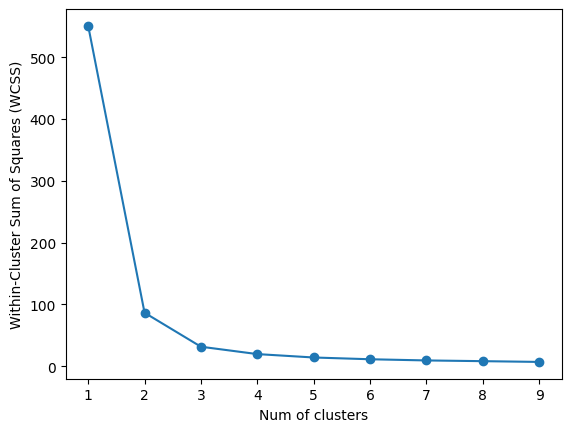

In [7]:
# 적절한 K 값을 추정해보기 위한 elbow method - WCSS 출력
inertias = []

for n in range(1, 10):
    # 모델 불러오기
    model = KMeans(n_clusters=n)

    # 모델 훈련하기
    model.fit(x_data)

    # 계산된 inertia 값을 추가하기
    inertias.append(model.inertia_)
    
plt.plot(range(1, 10), inertias, '-o')
plt.xlabel('Num of clusters')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.show()

### 2) "꽃잎의 길이"와 "너비" 뿐만 아니라 "꽃받침 길이"를 함께 고려하여 품종 분류를 해보자 (비지도학습, 분류, K-means clustering)

 - SepalLengthCm을 포함한 3가지 Feature로 K-means 클러스터링 (3D 시각화)

In [8]:
# 3D 시각화에 필요한 라이브러리 등에 대한 import
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
import plotly.express as px

In [9]:
## 데이터 전처리: Petal length, Petal width, Sepal length 들을 가지고 클러스터링 (그 외 데이터 삭제)
x_data_3d = df.drop(['SepalWidthCm'], axis=1)
#x_data_3d = df[['SepalLengthCm', 'PetalLengthCm', 'PetalWidthCm']]  # 동일한 결과를 내놓는 코드

x_data_3d

,SepalLengthCm,PetalLengthCm,PetalWidthCm
0,5.1,1.4,0.2
1,4.9,1.4,0.2
2,4.7,1.3,0.2
3,4.6,1.5,0.2
4,5.0,1.4,0.2
...,...,...,...
145,6.7,5.2,2.3
146,6.3,5.0,1.9
147,6.5,5.2,2.0
148,6.2,5.4,2.3


In [10]:
## 클러스터링 수행 by K-means clustering
# 알고리즘 선택과 불러오기 + cluster 수 설정
model_3d = KMeans(n_clusters=3) 

# 모델 학습
model_3d.fit(x_data_3d)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


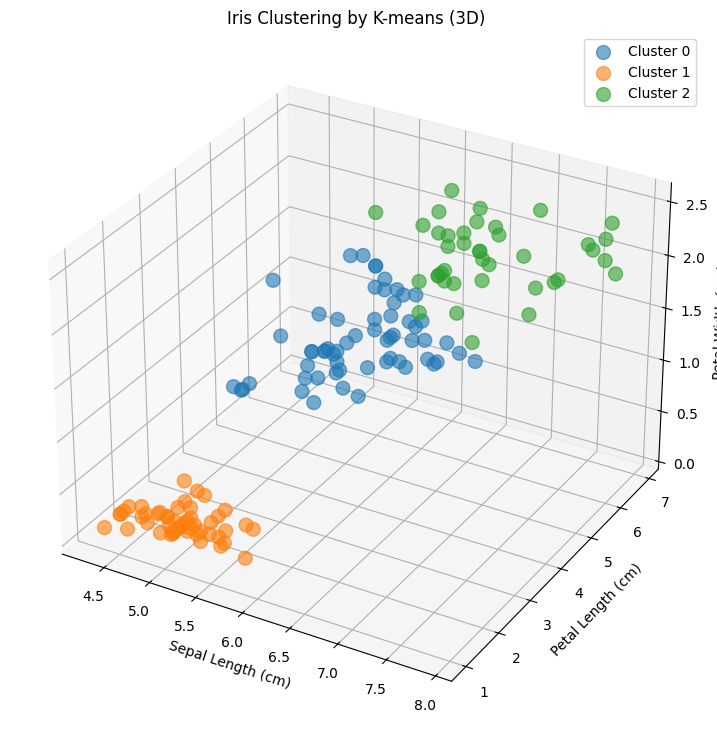

In [30]:
# 3D 산점도 그리기
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# 클러스별 포인트 scatter plot 그리기
for i in range(3):
    points = x_data_3d[model_3d.labels_ == i]
    ax.scatter(points['SepalLengthCm'], points['PetalLengthCm'], points['PetalWidthCm'], 
               label=f'Cluster {i}', s=100, alpha=0.6)

ax.set_xlabel('Sepal Length (cm)')
ax.set_ylabel('Petal Length (cm)')
ax.set_zlabel('Petal Width (cm)')
ax.set_title('Iris Clustering by K-means (3D)')
ax.legend()

plt.show()

### (옵션) Plotly를 사용한 인터랙티브 3D 산점도 (마우스 드래그로 회전 가능)

In [ ]:
import plotly.graph_objects as go
import plotly.express as px

# Plotly를 사용한 3D 산점도
fig = go.Figure()

# 각 클러스터별로 데이터 포인트 추가
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2']

for i in range(3):
    points = x_data_3d[model_3d.labels_ == i]
    fig.add_trace(go.Scatter3d(
        x=points['SepalLengthCm'],
        y=points['PetalLengthCm'],
        z=points['PetalWidthCm'],
        mode='markers',
        name=cluster_names[i],
        marker=dict(
            size=5,
            opacity=0.7
        )
    ))

# 레이아웃 설정
fig.update_layout(
    title='Iris Clustering by K-means (3D - Interactive)',
    scene=dict(
        xaxis_title='Sepal Length (cm)',
        yaxis_title='Petal Length (cm)',
        zaxis_title='Petal Width (cm)',
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.3)
        )
    ),
    width=900,
    height=700,
    hovermode='closest'
)

fig.show()

print("💡 Tip: 마우스를 드래그하여 3D 그래프를 회전시킬 수 있습니다!")
print("   - 좌측 버튼: 회전")
print("   - 우측 버튼: 이동")
print("   - 스크롤: 확대/축소")

💡 Tip: 마우스를 드래그하여 3D 그래프를 회전시킬 수 있습니다!
   - 좌측 버튼: 회전
   - 우측 버튼: 이동
   - 스크롤: 확대/축소
